<a href="https://colab.research.google.com/github/daviseemann/turbofan-rul-prediction-cmapss/blob/production/notebooks/pre-processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import drive
drive.mount('/content/drive/')
import os
os.chdir('/content/drive/MyDrive/Data science studies/Aprendizado-de-maquina-UFSC/final-project/data')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


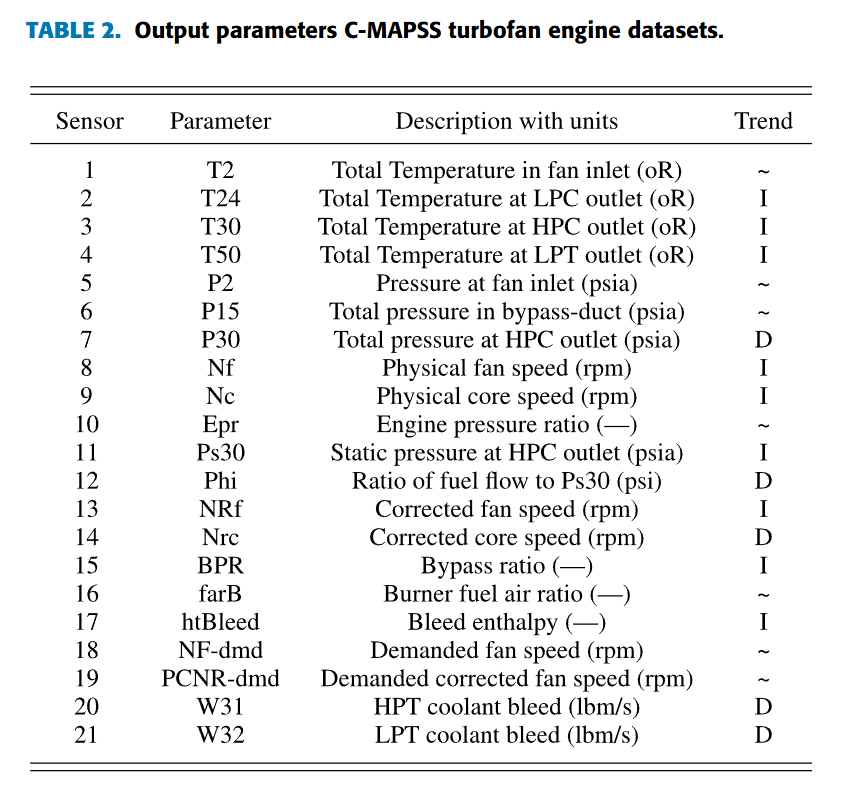

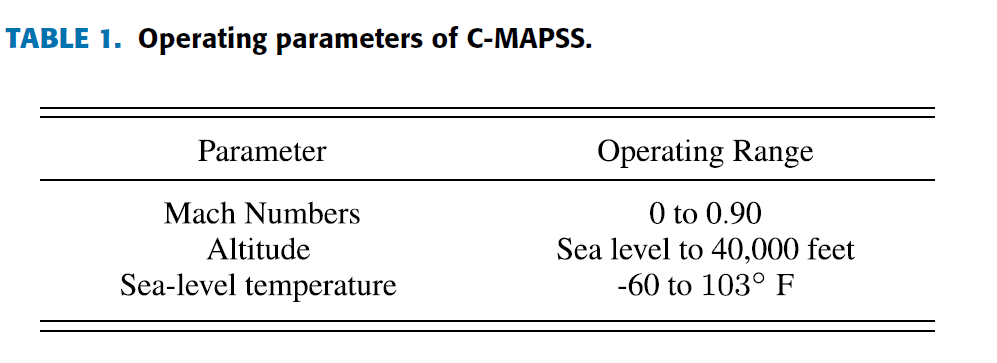

In [6]:
# Caminhos dos arquivos
train_path = "./6.turbofan rul/train_FD001.txt"
test_path = "./6.turbofan rul/test_FD001.txt"
rul_path = "./6.turbofan rul/RUL_FD001.txt"

# Nomes das colunas (de acordo com a documentação original do C-MAPSS)
column_names = ['engine_id', 'cycle'] + \
               [f'op_setting_{i}' for i in range(1, 4)] + \
               [f'sensor_measurement_{i}' for i in range(1, 22)]

# Importando os arquivos (espaço em branco como delimitador)
df_train = pd.read_csv(train_path, sep='\s+', header=None, names=column_names)
df_test = pd.read_csv(test_path, sep='\s+', header=None, names=column_names)
df_rul = pd.read_csv(rul_path, sep='\s+', header=None, names=['RUL'])

In [7]:
df_train.

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [46]:
df_train.to_csv("train_FD001.csv", index=False)

In [8]:
df_train.isnull().sum()

,0
engine_id,0
cycle,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_measurement_1,0
sensor_measurement_2,0
sensor_measurement_3,0
sensor_measurement_4,0
sensor_measurement_5,0


In [58]:
def calculate_rul(df_train):
    """
    Adiciona uma coluna 'RUL' ao df_train com base na diferença entre o ciclo máximo e o ciclo atual para cada motor.
    """
    max_cycles = df_train.groupby("engine_id")["cycle"].transform("max")
    df_train["RUL"] = max_cycles - df_train["cycle"]
    return df_train

calculate_rul(df_train)

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1


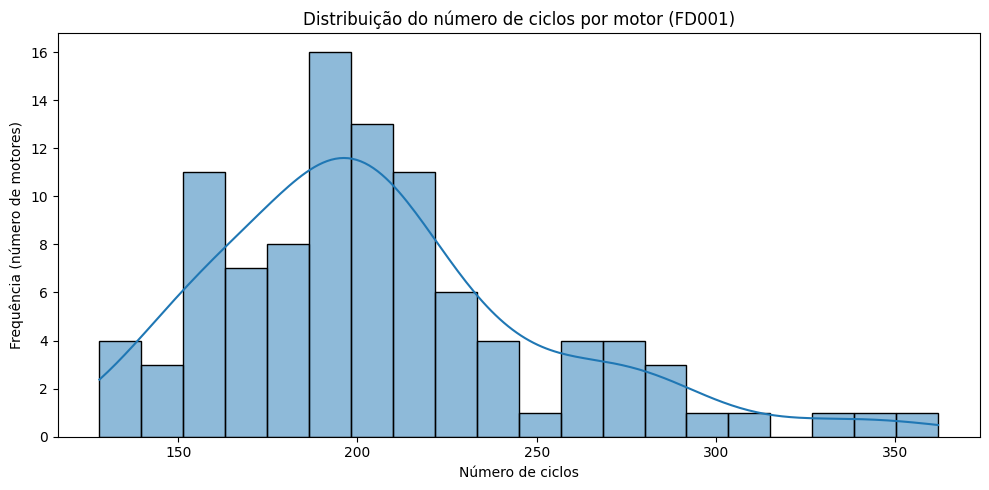

In [59]:
total_rows = len(df_train)
unique_engines = df_train['engine_id'].nunique()
rows_per_engine = df_train.groupby('engine_id').size()

plt.figure(figsize=(10, 5))
sns.histplot(rows_per_engine, bins=20, kde=True)
plt.title("Distribuição do número de ciclos por motor (FD001)")
plt.xlabel("Número de ciclos")
plt.ylabel("Frequência (número de motores)")
plt.tight_layout()
plt.show()

In [11]:
def plot_correlation(df_train):
    """
    Plota o mapa de calor das correlações dos sensores com a RUL.
    Retorna um DataFrame com as correlações ordenadas.
    """
    # Seleciona apenas as colunas de sensores
    sensor_cols = [col for col in df_train.columns if 'sensor' in col]

    # Calcula correlação com RUL
    correlation = df_train[sensor_cols + ['RUL']].corr()
    sensor_corr = correlation["RUL"].drop("RUL").sort_values(key=abs, ascending=False)

    # Mapa de calor visual
    plt.figure(figsize=(5, 6))
    sns.heatmap(sensor_corr.to_frame(), annot=True, cmap="coolwarm")
    plt.title("Correlação dos Sensores com RUL")
    plt.show()

    return sensor_corr


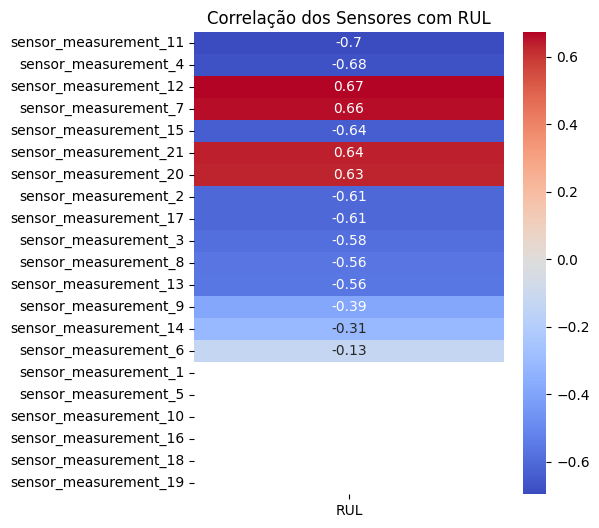

In [12]:
sensor_corr = plot_correlation(df_train)

As correlações entre o RUL e os dados dos sensores 1, 5, 10, 16, 18, 19 se mostraram inexistentes. Assim não serão considerados para o treinamento do modelo.

In [13]:
#Selecionando os sensores que tem correlação acima de 0.2

def selecionar_sensores(df, min_corr):
  # Seleciona apenas as colunas de sensores
    sensor_cols = [col for col in df.columns if 'sensor' in col]

    # Calcula correlação com RUL
    correlation = df[sensor_cols + ['RUL']].corr()
    sensor_corr = correlation[abs(correlation["RUL"])>min_corr].index.tolist()
    df = df[sensor_corr]
    return df

df_pre = selecionar_sensores(df_train,0.2)


In [36]:
# Vamos normalizar os dados dos sensores
df_pre.columns

def normalizar_dados(df):
  sensor_cols = [col for col in df.columns if 'sensor' in col]
  df.loc[:, sensor_cols] = (df[sensor_cols] - df[sensor_cols].mean()) / df[sensor_cols].std()
  return df

In [37]:
df_normalized = normalizar_dados(df_pre)
display(df_normalized)

,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_17,sensor_measurement_20,sensor_measurement_21,RUL
0,-1.721684,-0.134252,-0.925914,1.121113,-0.516326,-0.862792,-0.266460,0.334254,-1.058865,-0.269065,-0.603801,-0.781691,1.348460,1.194398,191
1,-1.061754,0.211523,-0.643710,0.431920,-0.798074,-0.958794,-0.191578,1.174871,-0.363637,-0.642829,-0.275845,-0.781691,1.016503,1.236892,190
2,-0.661797,-0.413156,-0.525940,1.008131,-0.234578,-0.557126,-1.015279,1.364688,-0.919819,-0.551616,-0.649128,-2.073044,0.739873,0.503411,189
3,-0.661797,-1.261284,-0.784812,1.222798,0.188044,-0.713808,-1.539452,1.961255,-0.224592,-0.520163,-1.971617,-0.781691,0.352590,0.777773,188
4,-0.621801,-1.251498,-0.301511,0.714376,-0.516326,-0.457048,-0.977838,1.052846,-0.780774,-0.521736,-0.339837,-0.136014,0.463242,1.059526,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,1.617961,1.216229,2.188322,-2.189276,1.315035,0.012546,1.979996,-2.607906,2.278227,-0.322534,1.425260,2.446692,-1.805129,-2.921042,4
20627,1.717950,2.279651,2.738285,-2.833277,1.878530,-0.006020,1.867673,-2.350298,1.722045,-0.380198,1.913194,1.155339,-2.856326,-1.203735,3
20628,1.477975,1.946924,2.138325,-2.742891,2.019404,0.029754,2.054877,-1.902872,2.000136,-0.141680,3.265013,3.092369,-2.081760,-3.292402,2
20629,1.098016,2.403608,1.955004,-3.036645,2.160278,0.383875,3.178105,-2.363856,1.861090,-0.233942,2.579771,1.155339,-2.911652,-2.085021,1


In [38]:
def nasa_score_if(y_true, y_pred):
    total_score = 0
    for yt, yp in zip(y_true, y_pred):
        e = yp - yt
        if e < 0:
            score = np.exp(-e / 13) - 1
        else:
            score = np.exp(e / 10) - 1
        total_score += score
    return total_score

In [44]:
df_train.drop_duplicates
df_train.shape

(20631, 27)